## Student Name: Gabriel Espinoza Rojas

## Student ID: 22176691

## Imports

In [451]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
%matplotlib inline
# for more beautiful plots
import seaborn as sns

# Task 1: Exploratory Data Analysis (EDA)

Perform EDA of the bank dataset by following the notebook <code>Tutorial 1-1 - Exploratory Data Analysis.ipynb</code> as an example.

1. Formulate a particular question that might be interesting to answer by exploring the bank dataset (approx. 50 words in a markdown cell).
2. Calculate statistics for the numerical and categorical attributes. Draw a short conclusion (approx. 150 words in a markdown cell).
3. Use at least two different plotting techniques to plot the distribution of some numerical attributes. Draw short conclusions (approx. 150 words in a markdown cell).
4. Generate at least two plots with the combined distribution of attributes. Draw a short conclusion (approx. 150 words in a markdown cell).
5. Make sure your conclusions are related to the question you have formulated.

In [452]:
# let's load up the data set and have a quick look 

bank_dataset = pd.read_csv("./bank.csv")

print(bank_dataset.dtypes)
print(bank_dataset.shape)
bank_dataset.head()

age           float64
job            object
marital        object
education      object
default        object
balance         int64
housing        object
loan           object
contact        object
day             int64
month          object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
subscribed     object
dtype: object
(2000, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
0,32.0,technician,single,tertiary,no,392,yes,no,cellular,1,apr,957,2,131,2,failure,no
1,39.0,technician,divorced,secondary,no,688,yes,yes,cellular,1,apr,233,2,133,1,failure,no
2,59.0,retired,married,secondary,no,1035,yes,yes,cellular,1,apr,126,2,239,1,failure,no
3,47.0,blue-collar,married,secondary,no,398,yes,yes,cellular,1,apr,274,1,238,2,failure,no
4,54.0,retired,married,secondary,no,1004,yes,no,cellular,1,apr,479,1,307,1,failure,no


In [453]:
bank_dataset.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
1995,20.0,student,single,NaN,no,2785,no,no,cellular,16,sep,327,2,-1,0,NaN,yes
1996,28.0,admin.,single,secondary,no,127,no,no,cellular,16,sep,1334,2,-1,0,NaN,yes
1997,81.0,retired,married,primary,no,1154,no,no,telephone,17,sep,231,1,-1,0,NaN,yes
1998,46.0,services,married,primary,no,4343,yes,no,NaN,20,sep,185,1,-1,0,NaN,yes
1999,40.0,entrepreneur,married,secondary,no,6403,no,no,cellular,22,sep,208,2,-1,0,NaN,yes


### 1. <strong>Formulate a particular question that might be interesting to answer by exploring the bank dataset </strong> (approx. 50 words in a markdown cell).



The dataset contains client-related and campaign information about bank calls promoting a subscription service. It would be interesting to know how factors like education level and occupation affects the subscription rate.

<!--"what affects subscription more? Education or occupation?"-->

<!--other good ones-->
<!--What influences the subscription success?-->

<!--Can I guess the balance of a customer just by the interaction with the bank?-->

<!--Can I guess the duration for the call for successful interactions.-->

<!--The bank wants to know what attributes matter the most to get more subscribers and improve their marketing campaign?-->

### <strong>2. Calculate statistics for the numerical and categorical attributes. Draw a short conclusion </strong> (approx. 150 words in a markdown cell).

In [454]:
# Print statistical summary for all numerical attributes
bank_dataset.describe()

,age,balance,day,duration,campaign,pdays,previous
count,1988.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,41.753018,1413.663500,13.851500,292.020500,1.909500,167.896000,2.561500
std,12.724358,3131.224213,9.712189,221.557295,1.378862,131.754126,3.400735
min,18.000000,-980.000000,1.000000,7.000000,1.000000,-1.000000,0.000000
25%,32.000000,201.500000,5.000000,146.000000,1.000000,75.750000,1.000000
50%,38.000000,551.000000,12.000000,236.000000,1.000000,182.000000,2.000000
75%,50.000000,1644.500000,23.000000,379.000000,2.000000,251.000000,3.000000
max,93.000000,81204.000000,31.000000,1823.000000,11.000000,854.000000,55.000000


In [455]:
categorical_cols = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome',
    'subscribed'
]
for col in categorical_cols:
    print(f"total count: {bank_dataset[col].count()}, frequency table: {bank_dataset[col].value_counts()} \n")

total count: 1990, frequency table: job
management       461
technician       348
blue-collar      298
admin.           247
services         165
retired          162
student           96
unemployed        69
self-employed     64
entrepreneur      45
housemaid         35
Name: count, dtype: int64 

total count: 2000, frequency table: marital
married     1111
single       674
divorced     215
Name: count, dtype: int64 

total count: 1896, frequency table: education
secondary    995
tertiary     684
primary      217
Name: count, dtype: int64 

total count: 2000, frequency table: default
no     1985
yes      15
Name: count, dtype: int64 

total count: 2000, frequency table: housing
no     1037
yes     963
Name: count, dtype: int64 

total count: 2000, frequency table: loan
no     1750
yes     250
Name: count, dtype: int64 

total count: 1809, frequency table: contact
cellular     1663
telephone     146
Name: count, dtype: int64 

total count: 2000, frequency table: month
feb    404
may    

### conclusions

The datasets has 17 columns. client-related are: 
age (numerical, values are missing), 
job (categorical, values are missing), 
marital (categorical), 
education (categorical, values are missing and there's an ordinal behaviour), 
default (categorical, binary behaviour), 
balance (numerical, presents strong outliers), 
housing (categorical, binary behaviour), 
loan (categorical, binary behaviour) 
and contact (categorical, values are missing). 


The campaign-related attributes are: 
day (numerical, cyclical behaviour), 
month (categorical, cyclical behaviour), 
duration (numerical, presents strong outliers), 
campaign (numerical), pdays (numerical), 
previous (numerical) 
and poutcome (categorical, values are missing). 

Together they add to 16, the last variable is the target: subscribed (categorical, binary behaviour).

### 3. <strong>Use at least two different plotting techniques to plot the distribution of some numerical attributes. Draw short conclusions</strong> (approx. 150 words in a markdown cell).

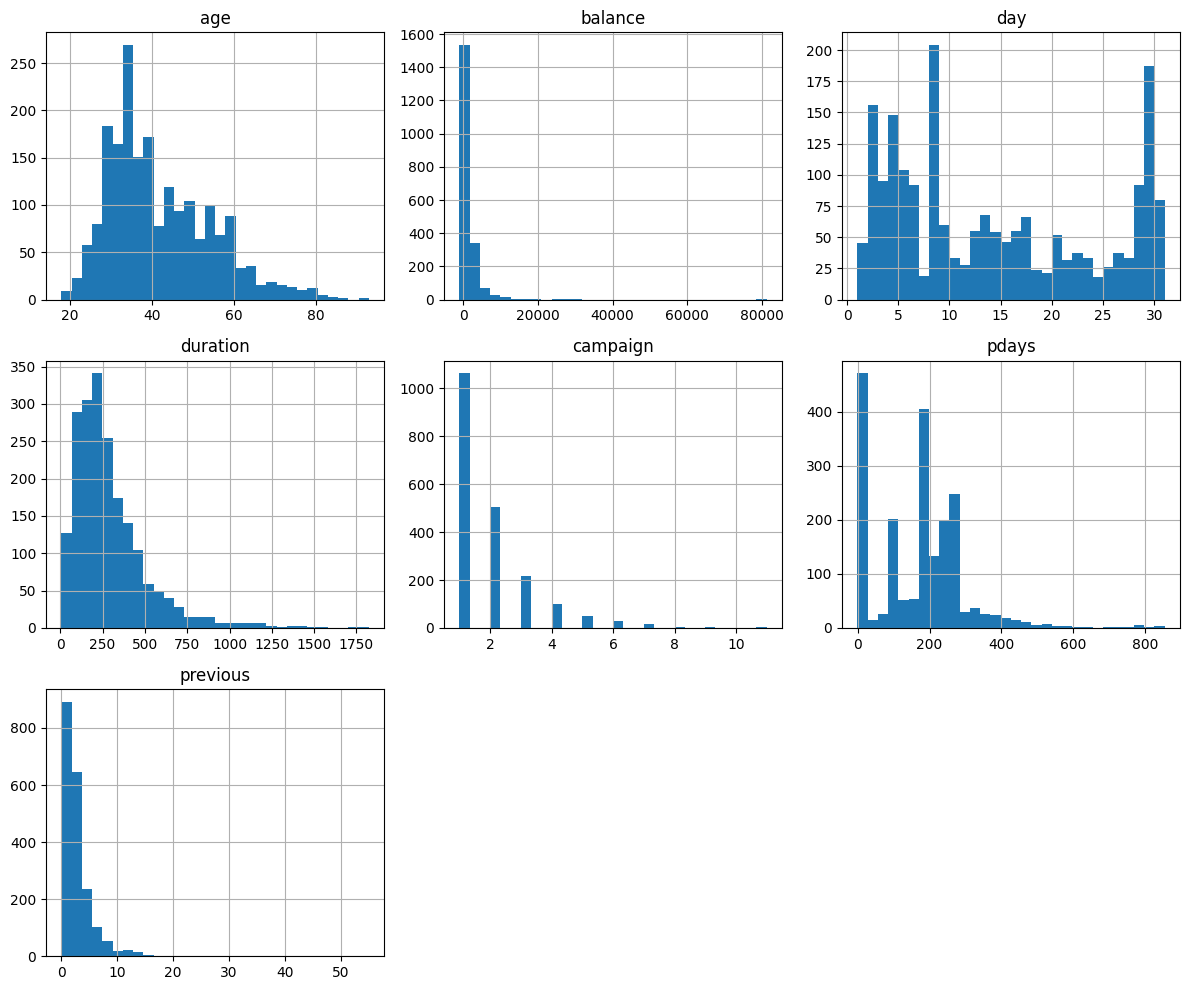

In [456]:
# histograms

relevant_columns = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
#relevant_columns = ['age', 'balance', 'duration', 'campaign', 'previous']

bank_dataset[relevant_columns].hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()

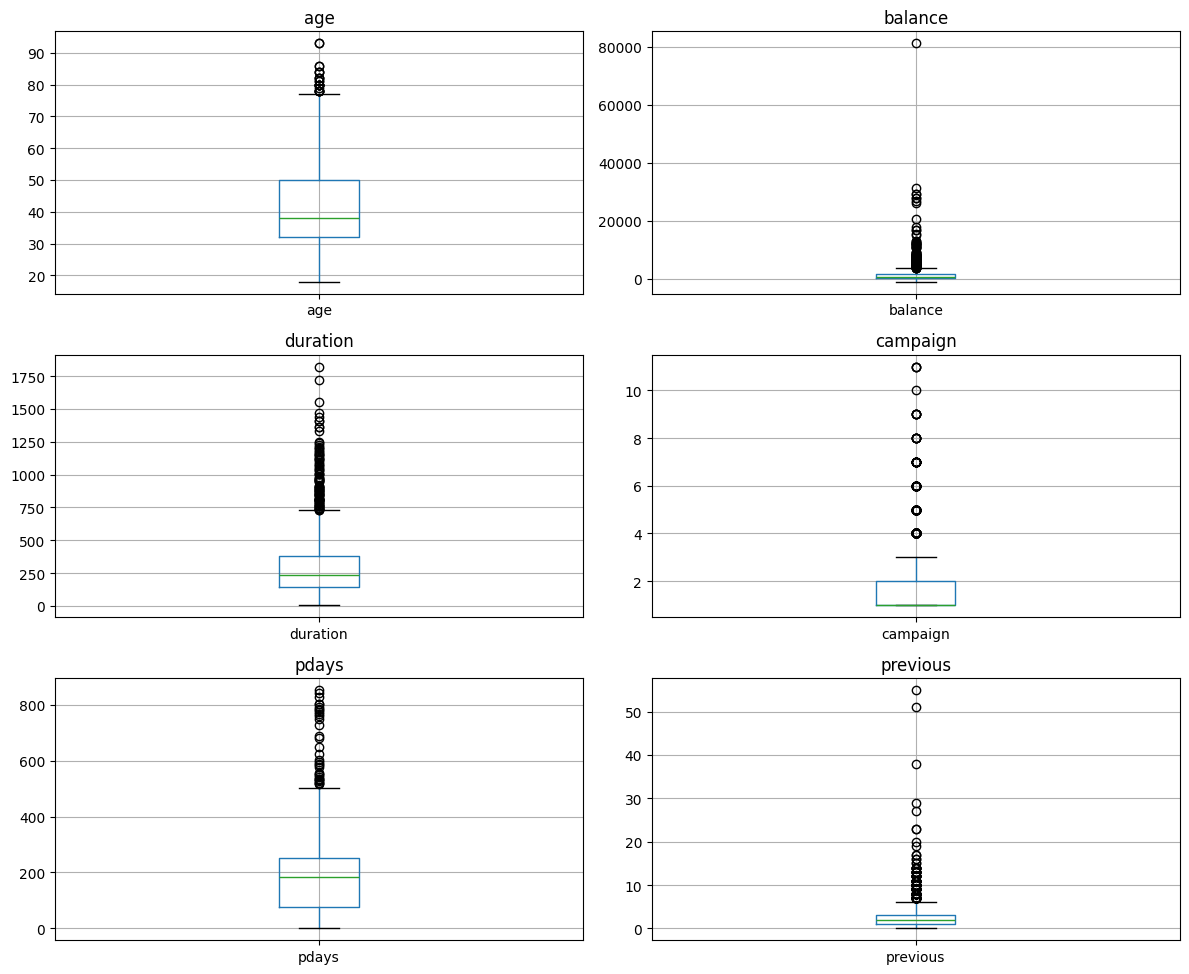

In [457]:
numeric_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

plt.figure(figsize=(12, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 2, i)
    bank_dataset.boxplot(column=col)
    plt.title(col)
    plt.suptitle("")  # removes automatic title

plt.tight_layout()
plt.show()

### conclusions

As suspected from the previous data, both 'balance' and 'duration' columns have outliers, and are also skewed. The cyclical behaviour in column 'day' works on a monthly basis. The 'campaign' column distribution is discrete. The nature of the 'pdays' column creates a strange distribution. It's also worth mentioning that distributions for 'campaign' and 'previous' columns are right-skewed, which is expected since they have many small values and a few large values.

### 4. <strong>Generate at least two plots with the combined distribution of attributes. Draw a short conclusion </strong>(approx. 150 words in a markdown cell).

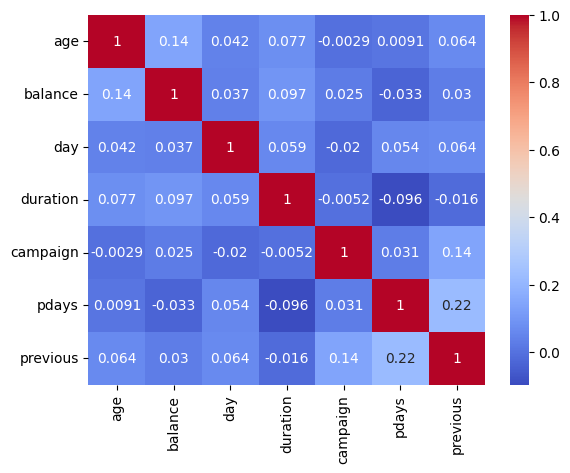

In [458]:
#correlation matrix
sns.heatmap(bank_dataset.corr(numeric_only=True), annot=True, cmap='coolwarm');

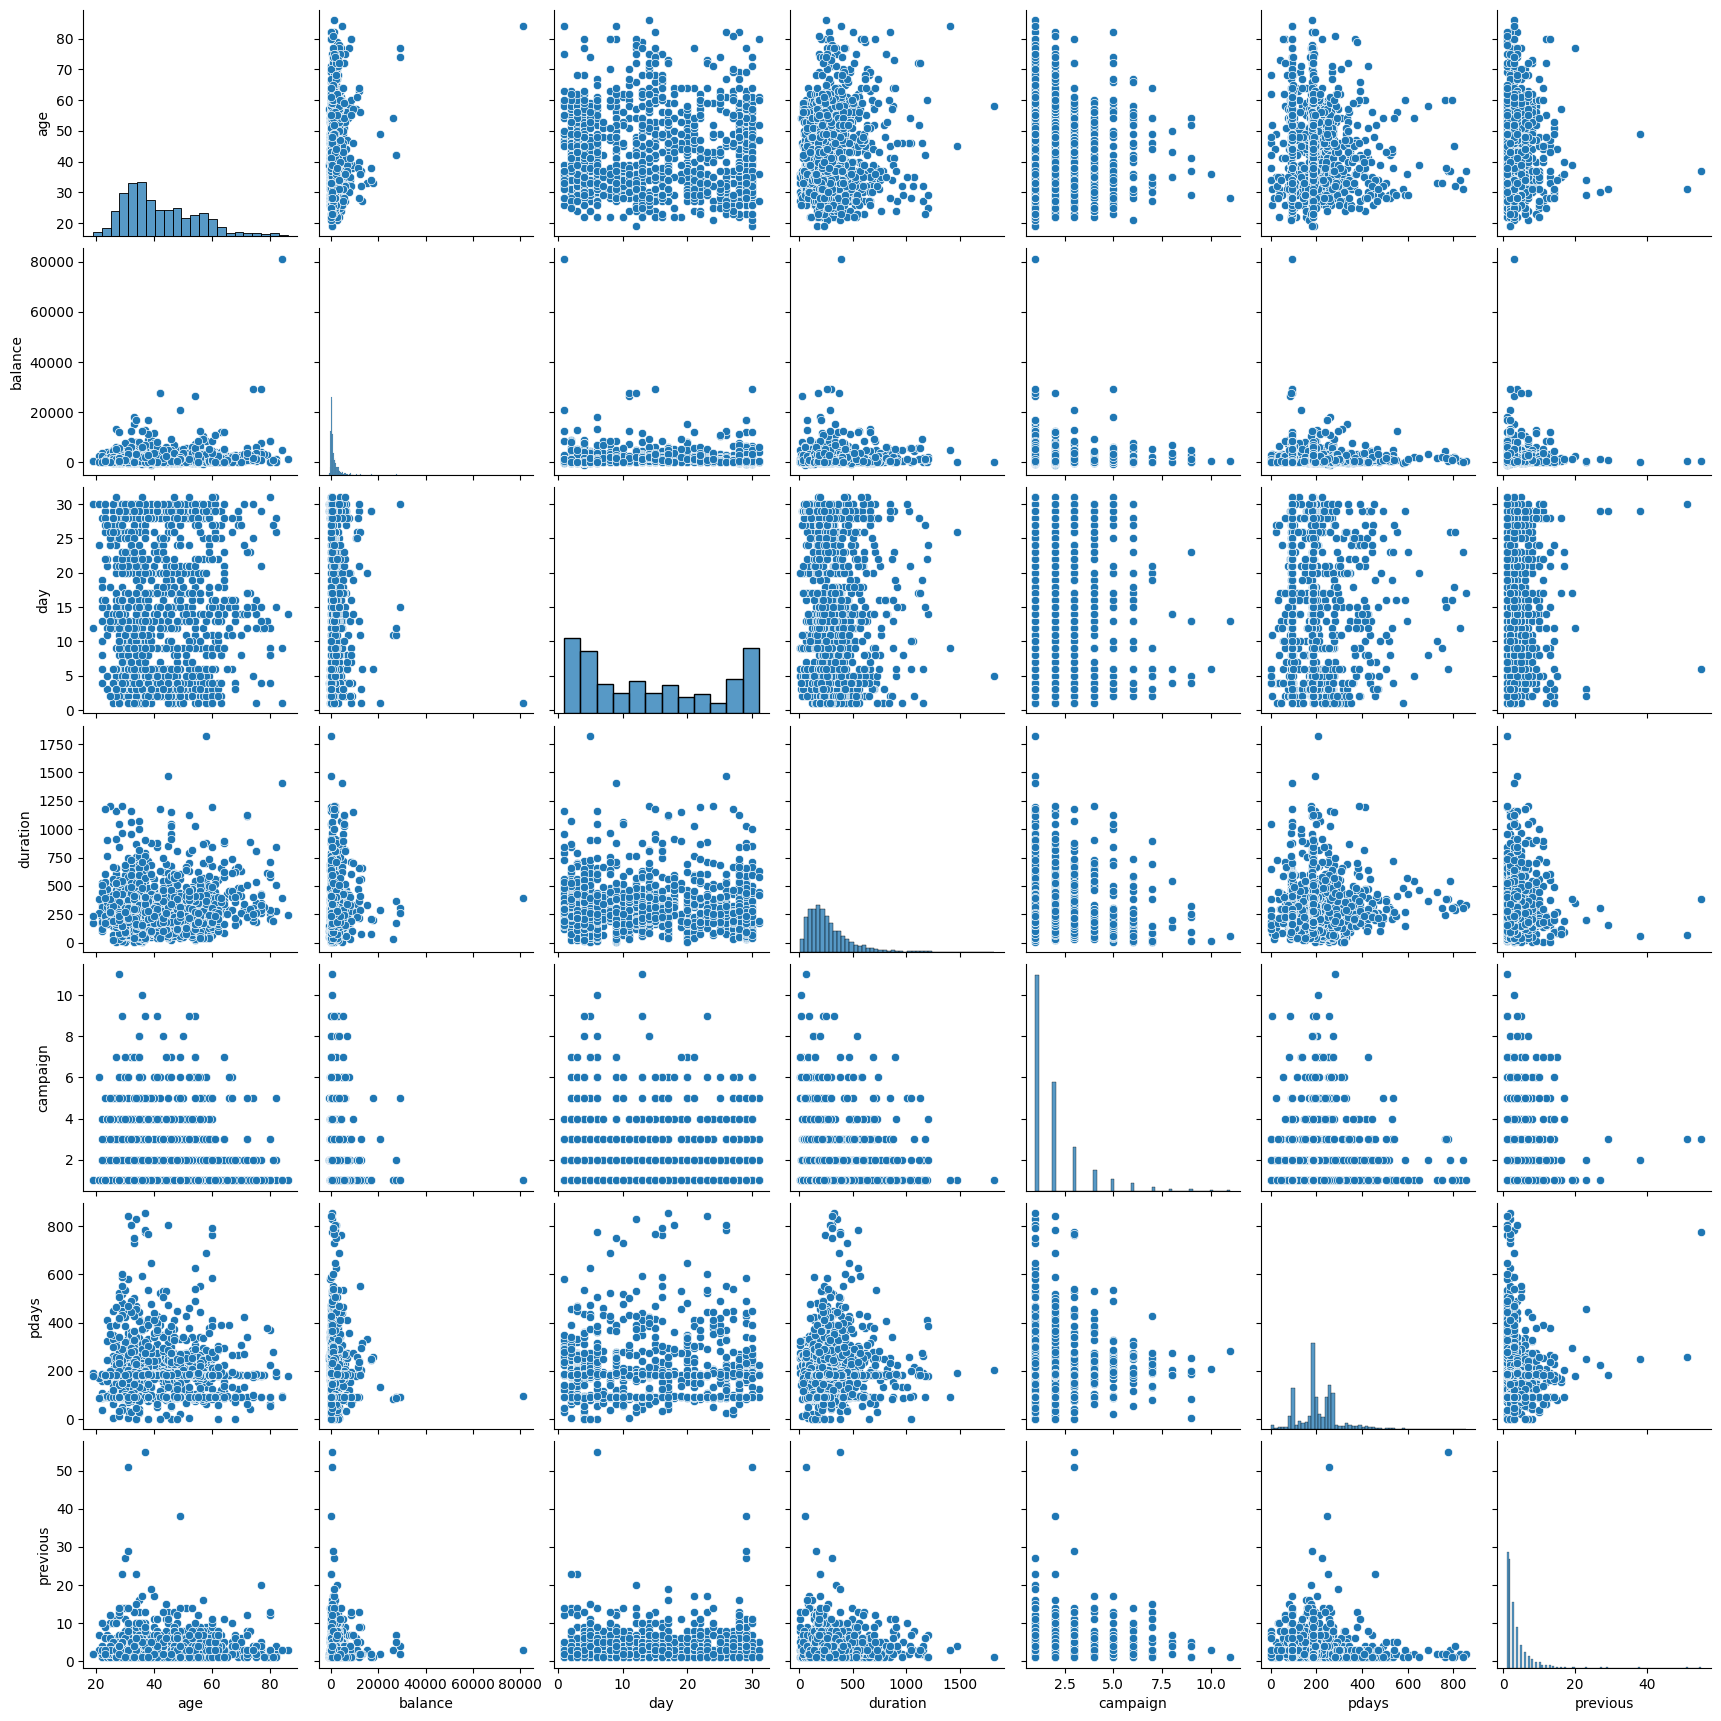

In [459]:
# note that by applying the method dropna() we drop all rows with missing values 
# looking for correlation
sns.pairplot(data=bank_dataset.dropna())
plt.show()

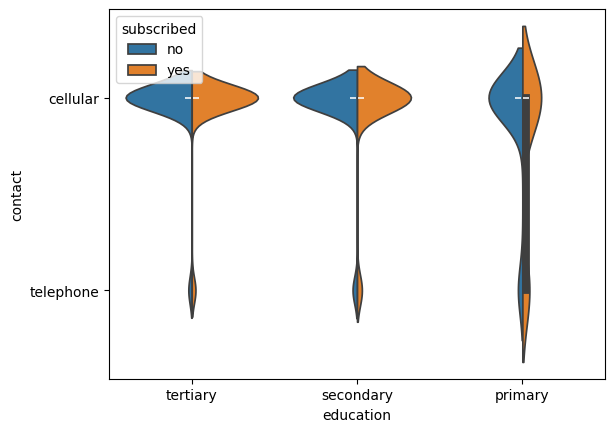

In [460]:
sns.violinplot(data=bank_dataset, x='education', y='contact', hue='subscribed', split=True)
plt.show()

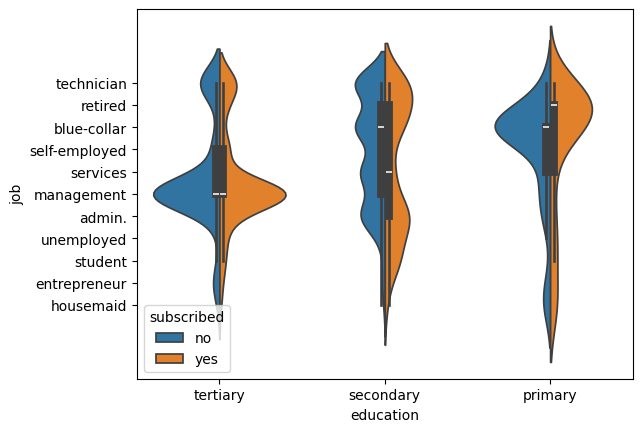

In [461]:
sns.violinplot(data=bank_dataset, x='education', y='job', hue='subscribed', split=True)
plt.show()

### Conclusions

Trends between certain occupations and certain levels of education start to emerge from the plots. Individuals with primary education and jobs: technician, retired or blue-collar are subscribing more. But not as much as individuals with tertiary education and jobs in: services, management and admin. And the secondary level of education has more of a bimodal distribution, with smaller peaks in subscriptions in both sets of jobs (with a slight influence from unemployed, student and entrepreneur occupations).


# Task 2: Data Preparation

Continue with preparing the bank dataset for machine learning by following the notebook <code>Tutorial 1-2 - Data Preparation.ipynb</code> as an example.

Ensure that you have:

1. encoded all categorical attributes as numerical,
2. filled in all missing values,
3. applied a scaler to rescale features,
4. treated outliers and skewed attribute distribution appropriately,
5. created at least one new feature from the existing ones.

Shortly describe and justify the data preparation choices you have made in markdown cells.

In [462]:
# Before we start transforming the dataset let's make a copy of it.
bank_dataset_original = bank_dataset

### 1. encoded all categorical attributes as numerical

In [483]:
# month column is categorical but also cyclical

# map month column to numerical values for cyclical transformation
month_map = {
    'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
    'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12
}

bank_dataset['month_num'] = bank_dataset['month'].map(month_map)

#cyclical encoding should reflect the true cycle, not the observed data range
max_month = 12 # max(bank_dataset['month_num'])

# apply cyclical encoding
bank_dataset['month_sin'] = np.sin(2 * np.pi * bank_dataset['month_num'] / max_month)
bank_dataset['month_cos'] = np.cos(2 * np.pi * bank_dataset['month_num'] / max_month)

# Drop original columns
bank_dataset.drop(columns=['month', 'month_num'], inplace=True)

#Note: the feature_engine library has a class that can perform this operation as well
#however, adding an extra library in the imports to performe this is undesirable.
#https://feature-engine.trainindata.com/en/latest/user_guide/creation/CyclicalFeatures.html
"""
from feature_engine.creation import CyclicalFeatures
bank_dataset['month_num'] = bank_dataset['month'].map(month_map)
cyc = CyclicalFeatures(
    variables=['month_num'],
    max_values={'month_num': 12,},
    drop_original=True
)
bank_dataset = cyc.fit_transform(bank_dataset)
"""

#let's encode the numerical day column in the same manner while we are at it

#cyclical encoding should reflect the true cycle, not the observed data range
max_day = 31 # max(bank_dataset['day'])

# apply cyclical encoding
bank_dataset['day_sin'] = np.sin(2 * np.pi * bank_dataset['day'] / max_day)
bank_dataset['day_cos'] = np.cos(2 * np.pi * bank_dataset['day'] / max_day)

# Drop original columns
bank_dataset.drop(columns=['day'], inplace=True)

# After encoding, always ensure the column has the correct numeric type.
bank_dataset.tail()

KeyError: 'month'

In [ ]:
# for conversations with peers, I understood one-hot encoding job
# could add noise. For ten values, the cure taxes more than the disease 
# so I'm imputating job column

bank_dataset[bank_dataset['job'].isna()]


,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,pdays,previous,poutcome,subscribed,month_sin,month_cos,day_sin,day_cos
255,42.0,NaN,single,primary,no,2398,yes,no,cellular,144,2,271,2,failure,no,0.866025,5.000000e-01,0.571268,0.820763
257,46.0,NaN,married,NaN,no,677,no,no,cellular,425,1,82,1,failure,no,0.866025,5.000000e-01,0.571268,0.820763
831,41.0,NaN,single,primary,no,2398,yes,no,NaN,287,2,-1,0,NaN,no,0.500000,-8.660254e-01,0.998717,-0.050649
1223,55.0,NaN,married,secondary,no,2206,no,no,cellular,265,1,91,5,success,yes,-0.866025,-5.000000e-01,0.651372,-0.758758
1281,50.0,NaN,married,NaN,no,558,no,no,cellular,464,1,683,6,failure,yes,-0.500000,-8.660254e-01,0.968077,-0.250653
1669,54.0,NaN,married,secondary,no,2206,no,no,cellular,260,1,91,4,success,yes,0.500000,-8.660254e-01,0.485302,-0.874347
1711,77.0,NaN,married,NaN,no,397,no,no,telephone,300,3,-1,0,NaN,yes,0.500000,-8.660254e-01,0.988468,0.151428
1801,28.0,NaN,single,NaN,no,326,no,no,cellular,450,1,231,1,success,yes,-0.866025,5.000000e-01,0.790776,-0.612106
1868,48.0,NaN,single,NaN,no,1819,no,no,cellular,1440,1,458,1,failure,yes,-1.000000,-1.836970e-16,0.394356,0.918958
1975,45.0,NaN,married,tertiary,no,406,no,no,cellular,314,1,-1,0,NaN,yes,-1.000000,-1.836970e-16,0.988468,0.151428


In [ ]:
# for conversations with peers, I understood one-hot encoding job
# could add noise. For ten values, the cure taxes more than the disease 
# so I'm imputating job column
"""
- job (Categorical): ("admin", "unemployed","management","housemaid","entrepreneur","student","blue-collar","self-employed","retired","technician","services") 
missing 2000-1990=10 values
"""

# Lori raised the fact that this specific individual is likely retired
bank_dataset.loc[
    (bank_dataset['age'] == 77) & (bank_dataset['job'].isna()),
    'job'
] = 'retired'

# the rest we can impute with the mode job of this dataset
bank_dataset['job'] = bank_dataset['job'].fillna(bank_dataset['job'].mode()[0])

In [ ]:
#the categorical features with missing values:
#https://queirozf.com/entries/one-hot-encoding-a-feature-on-a-pandas-dataframe-an-example

"""
- education (Categorical): education Level ("secondary","primary","tertiary") 
missing 2000-1896= 114 values

- contact (Categorical): ("telephone","cellular")
missing 2000-1809= 191 values

- poutcome (Categorical): ("other","failure","success") 
missing 2000-1546= 454 values
"""

# first one-hot encode the categorical columns with NaNs

bank_dataset = pd.get_dummies(bank_dataset, columns=['education', 'contact', 'poutcome'], 
                        dummy_na=True) 
                        #drop_first=True this attribute seems to be useful for we don't know what model it's going to be used

# Note: Prof. mentioned in class 'that's one of the way to do one hot encoding (using the function get_dummies from pandas), but there is actually a OneHotEncoder class in scikit-learn that's better'

# After encoding, always ensure the column has the correct numeric type.
bank_dataset.tail()

,age,job,marital,default,balance,housing,loan,duration,campaign,pdays,...,education_secondary,education_tertiary,education_nan,contact_cellular,contact_telephone,contact_nan,poutcome_failure,poutcome_other,poutcome_success,poutcome_nan
1995,20.0,student,single,no,2785,no,no,327,2,-1,...,False,False,True,True,False,False,False,False,False,True
1996,28.0,admin.,single,no,127,no,no,1334,2,-1,...,True,False,False,True,False,False,False,False,False,True
1997,81.0,retired,married,no,1154,no,no,231,1,-1,...,False,False,False,False,True,False,False,False,False,True
1998,46.0,services,married,no,4343,yes,no,185,1,-1,...,False,False,False,False,False,True,False,False,False,True
1999,40.0,entrepreneur,married,no,6403,no,no,208,2,-1,...,True,False,False,True,False,False,False,False,False,True


In [ ]:
#Categorical binary columns

"""
- default (Categorical/Binary): has credit in default? ("yes","no")

- housing (Categorical/Binary): has housing loan? ("yes","no")

- loan (Categorical/Binary): has personal loan? ("yes","no")

- subscribed (Categorical/Binary): has the client subscribed a term deposit? ("yes","no")
"""

binary_map = {'no': 0, 'yes': 1}

for col in ['default', 'housing', 'loan', 'subscribed']:
    bank_dataset[col] = bank_dataset[col].map(binary_map)

# After encoding, always ensure the column has the correct numeric type.
bank_dataset.tail()

,age,job,marital,default,balance,housing,loan,duration,campaign,pdays,...,education_secondary,education_tertiary,education_nan,contact_cellular,contact_telephone,contact_nan,poutcome_failure,poutcome_other,poutcome_success,poutcome_nan
1995,20.0,student,single,0,2785,0,0,327,2,-1,...,False,False,True,True,False,False,False,False,False,True
1996,28.0,admin.,single,0,127,0,0,1334,2,-1,...,True,False,False,True,False,False,False,False,False,True
1997,81.0,retired,married,0,1154,0,0,231,1,-1,...,False,False,False,False,True,False,False,False,False,True
1998,46.0,services,married,0,4343,1,0,185,1,-1,...,False,False,False,False,False,True,False,False,False,True
1999,40.0,entrepreneur,married,0,6403,0,0,208,2,-1,...,True,False,False,True,False,False,False,False,False,True


In [ ]:
# Before calling get_dummies, let's inspect what pandas thinks is categorical
bank_dataset.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

['job',
 'marital',
 'education_primary',
 'education_secondary',
 'education_tertiary',
 'education_nan',
 'contact_cellular',
 'contact_telephone',
 'contact_nan',
 'poutcome_failure',
 'poutcome_other',
 'poutcome_success',
 'poutcome_nan']

In [ ]:
# is this even necessary?
# one-hot encode categorical columns left

bank_dataset = pd.get_dummies(bank_dataset, columns=['marital']) 
#drop_first=True this attribute seems to be useful for we don't know what model it's going to be used

bank_dataset.tail()

,age,job,default,balance,housing,loan,duration,campaign,pdays,previous,...,contact_cellular,contact_telephone,contact_nan,poutcome_failure,poutcome_other,poutcome_success,poutcome_nan,marital_divorced,marital_married,marital_single
1995,20.0,student,0,2785,0,0,327,2,-1,0,...,True,False,False,False,False,False,True,False,False,True
1996,28.0,admin.,0,127,0,0,1334,2,-1,0,...,True,False,False,False,False,False,True,False,False,True
1997,81.0,retired,0,1154,0,0,231,1,-1,0,...,False,True,False,False,False,False,True,False,True,False
1998,46.0,services,0,4343,1,0,185,1,-1,0,...,False,False,True,False,False,False,True,False,True,False
1999,40.0,entrepreneur,0,6403,0,0,208,2,-1,0,...,True,False,False,False,False,False,True,False,True,False


2. filled in all missing values

In [ ]:
bank_dataset.isna().sum()

age                    12
job                     0
default                 0
balance                 0
housing                 0
loan                    0
duration                0
campaign                0
pdays                   0
previous                0
subscribed              0
month_sin               0
month_cos               0
day_sin                 0
day_cos                 0
education_primary       0
education_secondary     0
education_tertiary      0
education_nan           0
contact_cellular        0
contact_telephone       0
contact_nan             0
poutcome_failure        0
poutcome_other          0
poutcome_success        0
poutcome_nan            0
marital_divorced        0
marital_married         0
marital_single          0
dtype: int64

In [ ]:
"""
- age (Integer): missing 2000-1988=12 values
"""

#let's use the mean of each job to fill missing values

#easiest way to fill in the missing values is:
bank_dataset['age'] = bank_dataset['age'].fillna(bank_dataset['age'].mean())

3. applied a scaler to rescale features

In [ ]:
# outliers -> RobustScaler

"""
            balance     duration	campaign        pdays	    
mean	    1413.663500	292.020500	1.909500	167.896000	
std	    3131.224213	221.557295	1.378862	131.754126	
min	    -980.000000	7.000000	1.000000	-1.000000	
25%	    201.500000	146.000000	1.000000	75.750000	
50%	    551.000000	236.000000	1.000000	182.000000	
75%	   1644.500000	379.000000	2.000000	251.000000	
max	    81204.0000	1823.000000	11.000000	854.000000	
"""

robust_scaler = RobustScaler()
bank_dataset[['balance',
            'duration']] = robust_scaler.fit_transform(bank_dataset[['balance',
                                                                    'duration']])



In [ ]:
# Print statistical summary for all numerical attributes
bank_dataset.describe()

,age,default,balance,housing,loan,duration,campaign,pdays,previous,subscribed,month_sin,month_cos,day_sin,day_cos
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03,2000.000000,2000.000000
mean,41.753018,0.007500,0.597826,0.481500,0.125000,0.240431,1.909500,167.896000,2.561500,0.500000,0.218295,-7.347338e-02,0.200956,0.185124
std,12.686108,0.086299,2.169941,0.499783,0.330802,0.950890,1.378862,131.754126,3.400735,0.500125,0.685899,6.906266e-01,0.659767,0.700368
min,18.000000,0.000000,-1.060984,0.000000,0.000000,-0.982833,1.000000,-1.000000,0.000000,0.000000,-1.000000,-1.000000e+00,-0.998717,-0.994869
25%,32.000000,0.000000,-0.242204,0.000000,0.000000,-0.386266,1.000000,75.750000,1.000000,0.000000,-0.500000,-8.660254e-01,-0.394356,-0.440394
50%,38.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,182.000000,2.000000,0.500000,0.500000,-1.836970e-16,0.394356,0.347305
75%,50.000000,0.000000,0.757796,1.000000,0.000000,0.613734,2.000000,251.000000,3.000000,1.000000,0.866025,5.000000e-01,0.848644,0.820763
max,93.000000,1.000000,55.892585,1.000000,1.000000,6.811159,11.000000,854.000000,55.000000,1.000000,1.000000,1.000000e+00,0.998717,1.000000


4. treated outliers and skewed attribute distribution appropriately

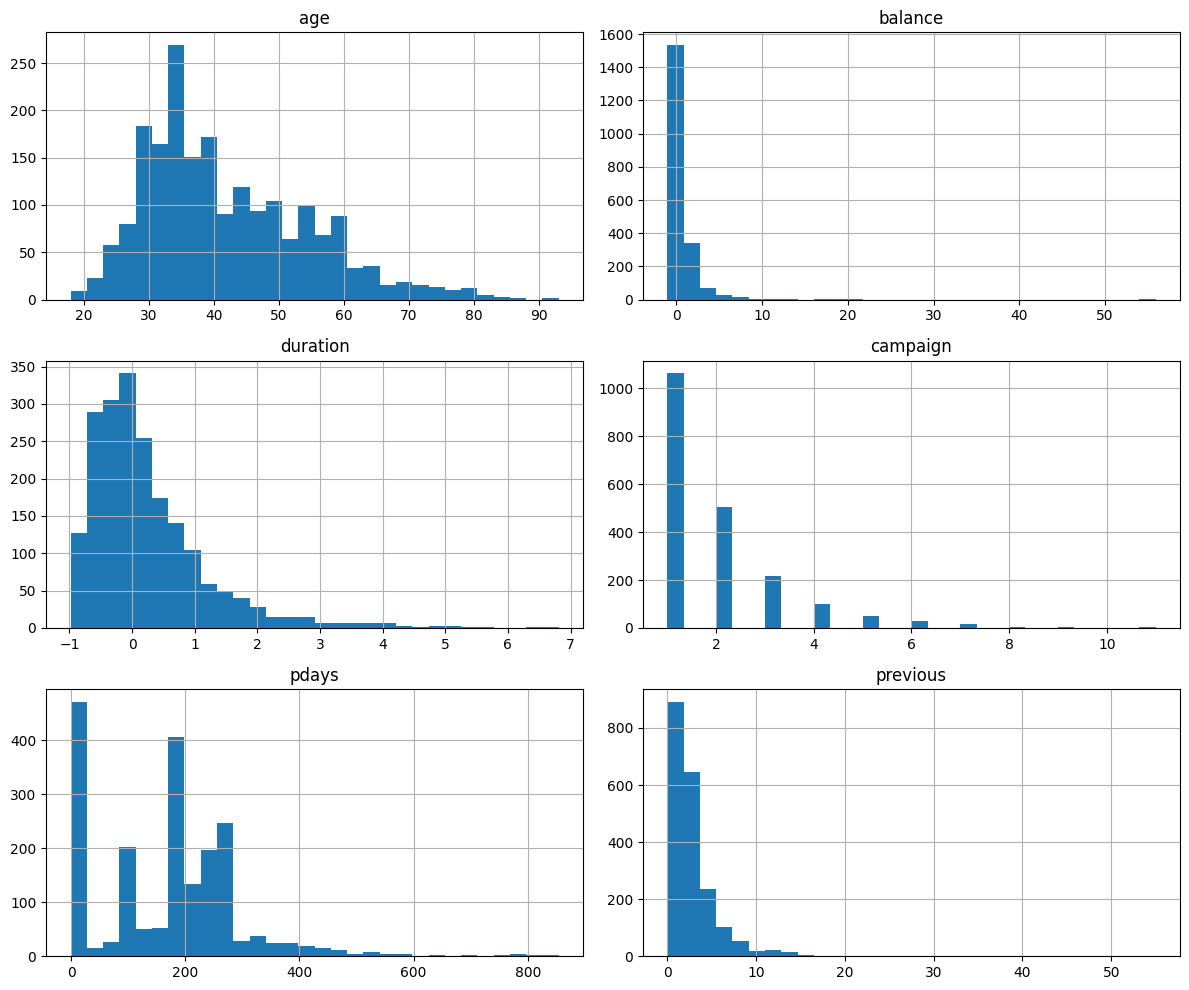

In [ ]:
# let's verify distributions

relevant_columns = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
#relevant_columns = ['age', 'balance', 'duration', 'campaign', 'previous']

bank_dataset[relevant_columns].hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()

Both histograms are skewed to the left, which is not ideal. Many ML algorithms work best when the features are not skewed to either side.

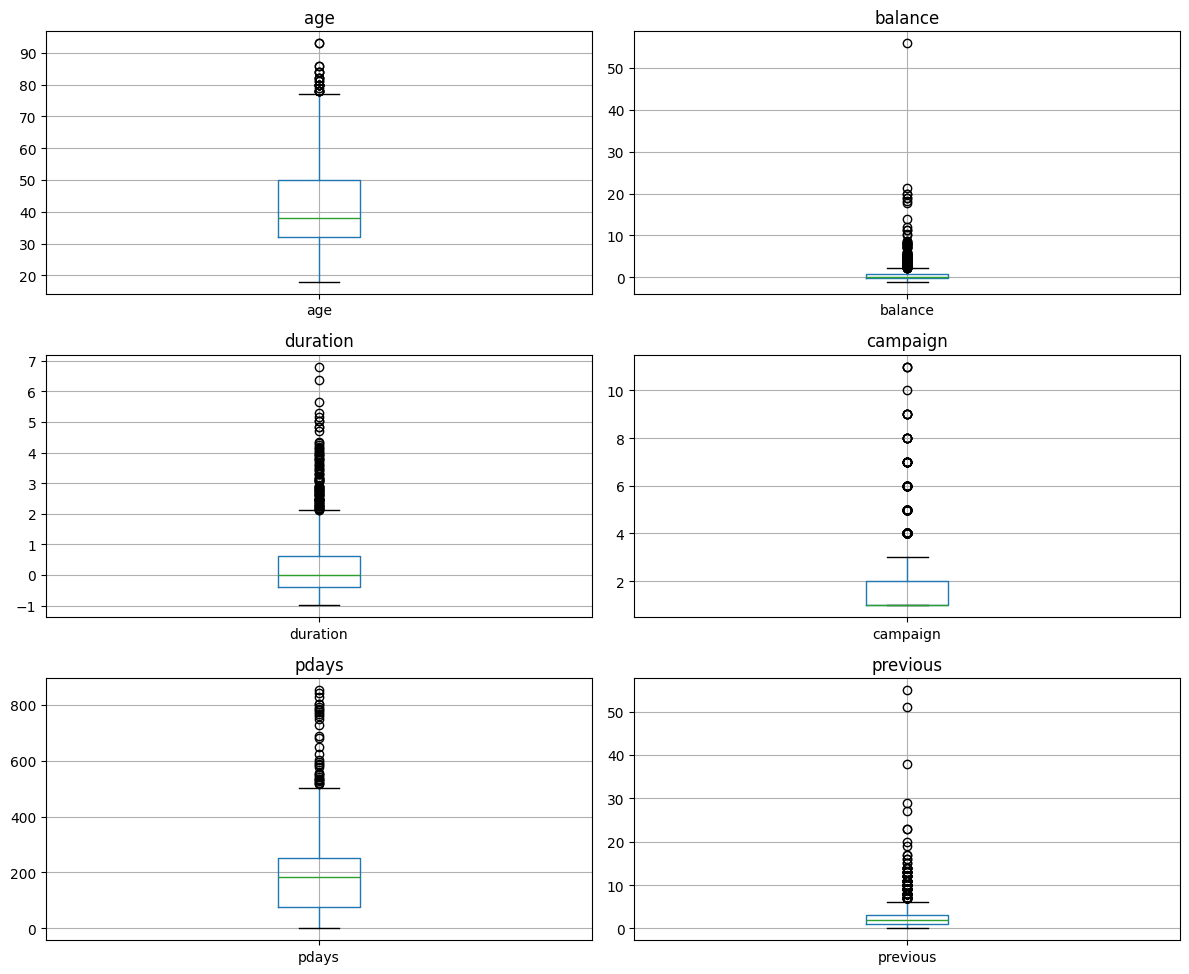

In [ ]:
numeric_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

plt.figure(figsize=(12, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 2, i)
    bank_dataset.boxplot(column=col)
    plt.title(col)
    plt.suptitle("")  # removes automatic title

plt.tight_layout()
plt.show()

In [ ]:
bank_dataset[['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']].min()

age         18.000000
balance     -1.060984
duration    -0.982833
campaign     1.000000
pdays       -1.000000
previous     0.000000
dtype: float64

<Figure size 1200x1000 with 0 Axes>

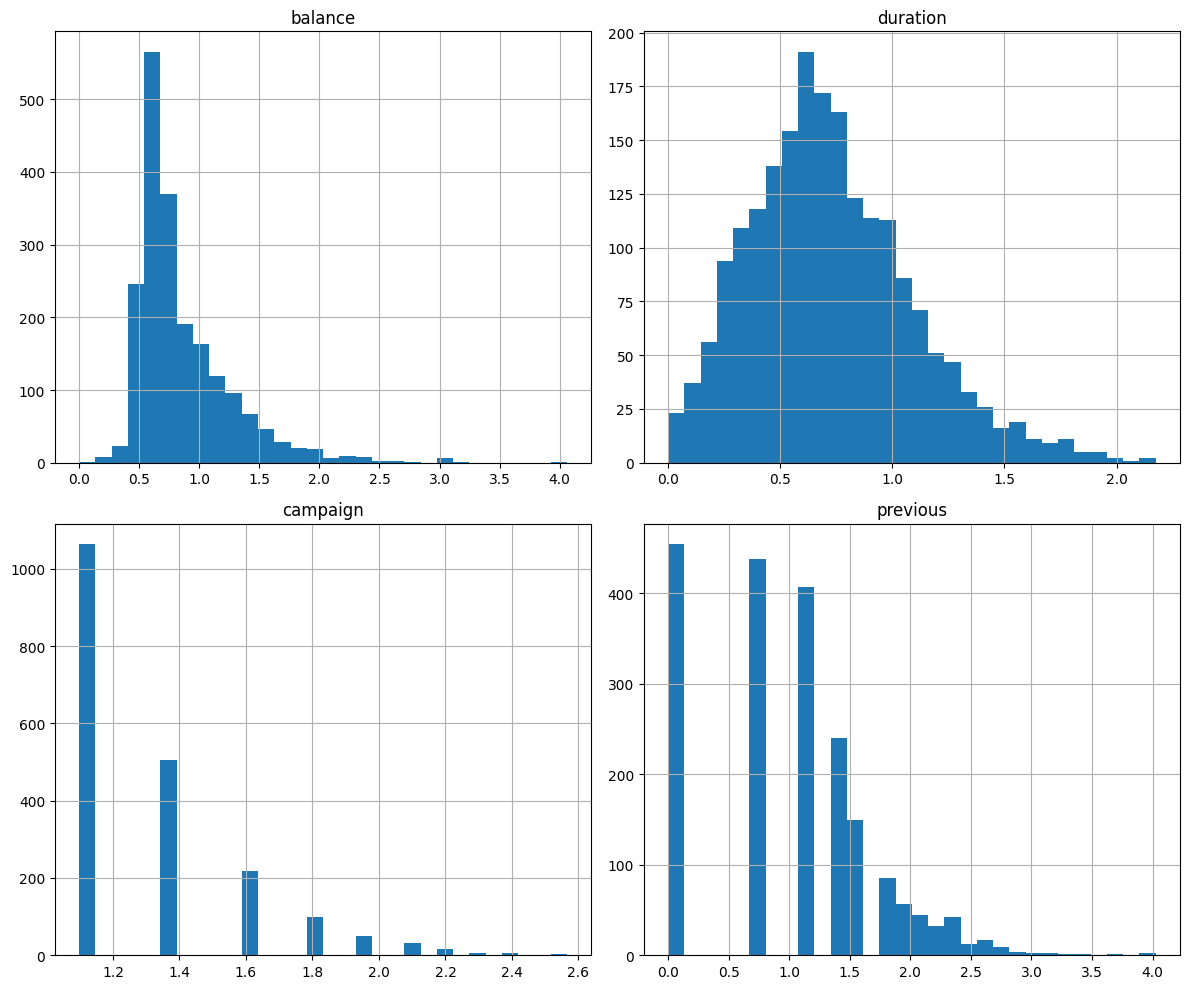

In [ ]:
# Use a log transformation to decrease the impact of outliers

numeric_cols = ['balance', 'duration', 'campaign', 'previous']

plt.figure(figsize=(12, 10))

for i, col in enumerate(numeric_cols, 1):
    bank_dataset[col] = np.log(bank_dataset[col] + abs(min(bank_dataset[col])) + 1)

bank_dataset[numeric_cols].hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()

For the columns 'day' and 'month', I used these transformations:  
$\text{month}_{\sin} = \sin\left(\frac{2\pi \cdot \text{month}}{12}\right)$, $\text{month}_{\sin} = \sin\left(\frac{2\pi \cdot \text{month}}{12}\right)$, $\text{month}_{\cos} = \cos\left(\frac{2\pi \cdot \text{month}}{12}\right)$ and $\text{day}_{\sin} = \sin\left(\frac{2\pi \cdot \text{day}}{31}\right)$
to model the cyclical behaviour. I'm aware that the feature_engine library has a class that can perform this operation as well. However, adding an extra library in the imports to perform this is something I'd avoid.

I used imputation over the columns 'job' (categorical) and 'age' (numerical). The former, to deal with 10 missing values, with one imputation being an educated guess and the rest using the mode of the column. For the 'age', I used the mean to imputate 12 missing values. The decision to use this techniques came from the realisation that the amounts of rows missing for both of these columns were relatively small (around $0.5%$ for the provided dataset).

For 'education', 'contact' and 'poutcome' columns, I used one-hot encoded <code>pd.get_dummies(bank_dataset, columns=[...], dummy_na=True)</code> since some values were missing. Note: Prof. mentioned in class 'that's one of the way to do one-hot encoding, but there is actually a <code>OneHotEncoder</code> class in scikit-learn that's better' (something to consider). I must mention that initially, I had decided that ordinal encoding the column 'education'. But after conversations with peers, due to the missing values, the argument to use an ordinal encoding weakens. It could still work but the missing values would need to be imputated, my mistake was using one-hot encoding to treat them.


 For columns 'default', 'housing', 'loan' and 'subscribed', I used binary mapping due to their values all being 'yes' or 'no'.
 
 
For encoding categorical columns without missing values ('marital') I used get_dummies again without <code>dummy_na=True</code>. 


To deal with outliers in 'balance' and 'duration' columns, I used </code>RobustScaler</code>. And then a log transformation over columns 'balance', 'duration', 'campaign' and 'previous' to provide a Gaussian-like distribution.

5. created at least one new feature from the existing ones

In [ ]:
bank_dataset['pdays_contacted'] = (bank_dataset['pdays'] != -1).astype(int)

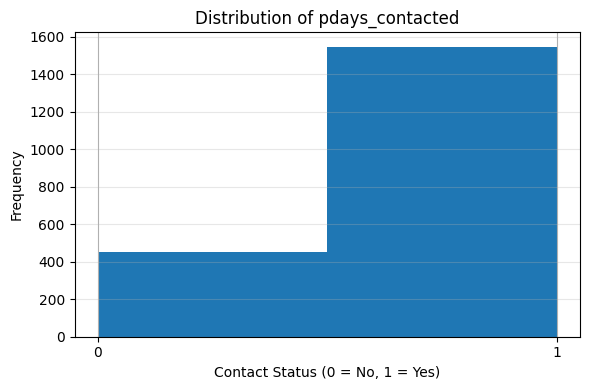

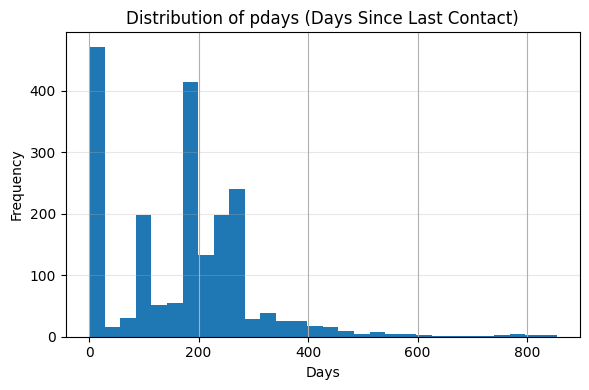

In [ ]:
# check is new feature has a better distribution

# pdays_contacted
plt.figure(figsize=(6, 4))
bank_dataset['pdays_contacted'].hist(bins=2)
plt.title('Distribution of pdays_contacted')
plt.xlabel('Contact Status (0 = No, 1 = Yes)')
plt.ylabel('Frequency')
plt.xticks([0, 1])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# Clean pdays
bank_dataset['pdays'] = bank_dataset['pdays'].replace(-1, 0)

# pdays distribution
plt.figure(figsize=(6, 4))
bank_dataset['pdays'].hist(bins=30)
plt.title('Distribution of pdays (Days Since Last Contact)')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<!--"It's worth noting that -1 in pdays is 100% correlated with the 0 value in 'previous'."-->
I created a new feature to better capture the information from the 'pdays' column. The pday column is special because it has a categorial meaning but only numerical values. When it is -1, the individual has never been contacted before, any other number means how many days since the last contact. So the column 'pdays_contacted' comes to answer in a straight-forward manner if the individual has ever been contacted before, leaving the 'pdays' value to only represent how long ago the interaction happened. 